# **1. Import Libraries 📚**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

## **2 Movide Dataset 🔢**:

In [ ]:
movie_data = pd.read_csv('TMDB_movie_dataset_v11 (2015-2023).csv')

In [ ]:
movie_data.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,293660,Deadpool,7.606,28894,Released,2/9/2016,783100000,108,False,/en971MEXui9diirXlogOrPKmsEn.jpg,...,Deadpool,The origin story of former Special Forces oper...,72.735,/zq8Cl3PNIDGU3iWNRoc5nEZ6pCe.jpg,Witness the beginning of a happy ending.,"Action, Adventure, Comedy","20th Century Fox, The Donners' Company, Genre ...",United States of America,English,"superhero, anti hero, mercenary, based on comi..."
1,299536,Avengers: Infinity War,8.255,27713,Released,4/25/2018,2052415039,149,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,...,Avengers: Infinity War,As the Avengers and their allies have continue...,154.340,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,An entire universe. Once and for all.,"Adventure, Action, Science Fiction",Marvel Studios,United States of America,"English, Xhosa","sacrifice, magic, superhero, based on comic, s..."
2,299534,Avengers: Endgame,8.263,23857,Released,4/24/2019,2800000000,181,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,...,Avengers: Endgame,After the devastating events of Avengers: Infi...,91.756,/or06FN3Dka5tukK1e9sl16pB3iy.jpg,Avenge the fallen.,"Adventure, Science Fiction, Action",Marvel Studios,United States of America,"English, Japanese, Xhosa","superhero, time travel, space travel, time mac..."
3,475557,Joker,8.168,23425,Released,10/1/2019,1074458282,122,False,/hO7KbdvGOtDdeg0W4Y5nKEHeDDh.jpg,...,Joker,"During the 1980s, a failed stand-up comedian i...",54.522,/udDclJoHjfjb8Ekgsd4FDteOkCU.jpg,Put on a happy face.,"Crime, Thriller, Drama","Warner Bros. Pictures, Joint Effort, Village R...","Canada, United States of America",English,"dream, street gang, society, psychopath, clown..."
4,99861,Avengers: Age of Ultron,7.276,21754,Released,4/22/2015,1405403694,141,False,/6YwkGolwdOMNpbTOmLjoehlVWs5.jpg,...,Avengers: Age of Ultron,When Tony Stark tries to jumpstart a dormant p...,96.565,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,A new age has come.,"Action, Adventure, Science Fiction",Marvel Studios,United States of America,English,"artificial intelligence (a.i.), superhero, bas..."


# **3. Transform data 🛠️**

In [ ]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259634 entries, 0 to 259633
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    259634 non-null  int64  
 1   title                 259632 non-null  object 
 2   vote_average          259634 non-null  float64
 3   vote_count            259634 non-null  int64  
 4   status                259634 non-null  object 
 5   release_date          259634 non-null  object 
 6   revenue               259634 non-null  int64  
 7   runtime               259634 non-null  int64  
 8   adult                 259634 non-null  bool   
 9   backdrop_path         113599 non-null  object 
 10  budget                259634 non-null  int64  
 11  homepage              46325 non-null   object 
 12  imdb_id               126758 non-null  object 
 13  original_language     259634 non-null  object 
 14  original_title        259632 non-null  object 
 15  

## -1 Change Data Type

In [ ]:
for col in movie_data.columns:
    if movie_data[col].dtype == 'object':
        movie_data[col] = movie_data[col].astype('category')

In [ ]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259634 entries, 0 to 259633
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   id                    259634 non-null  int64   
 1   title                 259632 non-null  category
 2   vote_average          259634 non-null  float64 
 3   vote_count            259634 non-null  int64   
 4   status                259634 non-null  category
 5   release_date          259634 non-null  category
 6   revenue               259634 non-null  int64   
 7   runtime               259634 non-null  int64   
 8   adult                 259634 non-null  bool    
 9   backdrop_path         113599 non-null  category
 10  budget                259634 non-null  int64   
 11  homepage              46325 non-null   category
 12  imdb_id               126758 non-null  category
 13  original_language     259634 non-null  category
 14  original_title        259632 non-nul

## -2 Delete Duplicates

Check for duplicates

In [ ]:
duplicates = movie_data.duplicated()

print(f"Number of duplicates: {duplicates.sum()} 📋")

Number of duplicates: 66 📋


Delete duplicates

In [ ]:
movie_data.drop_duplicates(inplace=True)

In [ ]:
duplicates_after_deletion = movie_data.duplicated()

print(f"Number of duplicates now: {duplicates_after_deletion.sum()} 📋")

Number of duplicates now: 0 📋


In [ ]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 259568 entries, 0 to 259633
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   id                    259568 non-null  int64   
 1   title                 259566 non-null  category
 2   vote_average          259568 non-null  float64 
 3   vote_count            259568 non-null  int64   
 4   status                259568 non-null  category
 5   release_date          259568 non-null  category
 6   revenue               259568 non-null  int64   
 7   runtime               259568 non-null  int64   
 8   adult                 259568 non-null  bool    
 9   backdrop_path         113583 non-null  category
 10  budget                259568 non-null  int64   
 11  homepage              46316 non-null   category
 12  imdb_id               126738 non-null  category
 13  original_language     259568 non-null  category
 14  original_title        259566 non-null  ca

## -3 Delete Unnecessary Columns

In [ ]:
for col in movie_data.columns:
    if col in ['id', 'backdrop_path', 'homepage', 'poster_path', 'overview', 'backdrop_path', 'homepage', 'imdb_id', 'original_title', 'tagline', 'spoken_languages','keywords']:
        movie_data.drop(col, axis=1, inplace=True)

In [ ]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 259568 entries, 0 to 259633
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   title                 259566 non-null  category
 1   vote_average          259568 non-null  float64 
 2   vote_count            259568 non-null  int64   
 3   status                259568 non-null  category
 4   release_date          259568 non-null  category
 5   revenue               259568 non-null  int64   
 6   runtime               259568 non-null  int64   
 7   adult                 259568 non-null  bool    
 8   budget                259568 non-null  int64   
 9   original_language     259568 non-null  category
 10  popularity            259568 non-null  float64 
 11  genres                179102 non-null  category
 12  production_companies  139006 non-null  category
 13  production_countries  163923 non-null  category
dtypes: bool(1), category(7), float64(2), int6

## -4 Keep "Released" Status

In [ ]:
movie_data['status'].unique()

['Released', 'Planned', 'In Production', 'Post Production', 'Canceled', 'Rumored']
Categories (6, object): ['Canceled', 'In Production', 'Planned', 'Post Production', 'Released',
                         'Rumored']

In [ ]:
movie_data = movie_data[movie_data['status'] == 'Released']

In [ ]:
movie_data['status'].unique()

['Released']
Categories (6, object): ['Canceled', 'In Production', 'Planned', 'Post Production', 'Released',
                         'Rumored']

In [ ]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257480 entries, 0 to 259633
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   title                 257478 non-null  category
 1   vote_average          257480 non-null  float64 
 2   vote_count            257480 non-null  int64   
 3   status                257480 non-null  category
 4   release_date          257480 non-null  category
 5   revenue               257480 non-null  int64   
 6   runtime               257480 non-null  int64   
 7   adult                 257480 non-null  bool    
 8   budget                257480 non-null  int64   
 9   original_language     257480 non-null  category
 10  popularity            257480 non-null  float64 
 11  genres                177407 non-null  category
 12  production_companies  137954 non-null  category
 13  production_countries  162555 non-null  category
dtypes: bool(1), category(7), float64(2), int6

In [ ]:
# Delete Unecessary "Status" Column
movie_data.drop('status', axis=1, inplace=True)

In [ ]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257480 entries, 0 to 259633
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   title                 257478 non-null  category
 1   vote_average          257480 non-null  float64 
 2   vote_count            257480 non-null  int64   
 3   release_date          257480 non-null  category
 4   revenue               257480 non-null  int64   
 5   runtime               257480 non-null  int64   
 6   adult                 257480 non-null  bool    
 7   budget                257480 non-null  int64   
 8   original_language     257480 non-null  category
 9   popularity            257480 non-null  float64 
 10  genres                177407 non-null  category
 11  production_companies  137954 non-null  category
 12  production_countries  162555 non-null  category
dtypes: bool(1), category(6), float64(2), int64(4)
memory usage: 30.9 MB


## -5 Fill Missing Values:

### - 5.1 Fill title:

In [ ]:
cols_to_fill = ['title']

for col in cols_to_fill:
    movie_data[col] = movie_data[col].cat.add_categories('N/A').fillna('N/A')

### - 5.2 Fill genres ,production_companies and production_countries

In [ ]:
cols_to_fill_1 = ['production_countries', 'production_companies', 'genres']

for col in cols_to_fill_1:
    movie_data[col] = movie_data[col].cat.add_categories('Other').fillna('Other')

In [ ]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257480 entries, 0 to 259633
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   title                 257480 non-null  category
 1   vote_average          257480 non-null  float64 
 2   vote_count            257480 non-null  int64   
 3   release_date          257480 non-null  category
 4   revenue               257480 non-null  int64   
 5   runtime               257480 non-null  int64   
 6   adult                 257480 non-null  bool    
 7   budget                257480 non-null  int64   
 8   original_language     257480 non-null  category
 9   popularity            257480 non-null  float64 
 10  genres                257480 non-null  category
 11  production_companies  257480 non-null  category
 12  production_countries  257480 non-null  category
dtypes: bool(1), category(6), float64(2), int64(4)
memory usage: 30.9 MB


## -6 Add Profit Columns

In [ ]:
movie_data['profit'] = movie_data['revenue'] - movie_data['budget']

## -7 Add ROI Column

In [ ]:
movie_data['ROI'] = np.where(
    movie_data['budget'] == 0,
    0,
    movie_data['profit'] / movie_data['budget']
)

In [ ]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257480 entries, 0 to 259633
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   title                 257480 non-null  category
 1   vote_average          257480 non-null  float64 
 2   vote_count            257480 non-null  int64   
 3   release_date          257480 non-null  category
 4   revenue               257480 non-null  int64   
 5   runtime               257480 non-null  int64   
 6   adult                 257480 non-null  bool    
 7   budget                257480 non-null  int64   
 8   original_language     257480 non-null  category
 9   popularity            257480 non-null  float64 
 10  genres                257480 non-null  category
 11  production_companies  257480 non-null  category
 12  production_countries  257480 non-null  category
 13  profit                257480 non-null  int64   
 14  ROI                   257480 non-null  fl

## -8 Keep only main genres main and production_companies

In [ ]:
for col in movie_data.columns:
    if col in ['genres', 'production_companies', 'production_countries']:
        movie_data[col] = movie_data[col].str.split(', ').str[0]
        movie_data[col] = movie_data[col].astype('category')

In [ ]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257480 entries, 0 to 259633
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   title                 257480 non-null  category
 1   vote_average          257480 non-null  float64 
 2   vote_count            257480 non-null  int64   
 3   release_date          257480 non-null  category
 4   revenue               257480 non-null  int64   
 5   runtime               257480 non-null  int64   
 6   adult                 257480 non-null  bool    
 7   budget                257480 non-null  int64   
 8   original_language     257480 non-null  category
 9   popularity            257480 non-null  float64 
 10  genres                257480 non-null  category
 11  production_companies  257480 non-null  category
 12  production_countries  257480 non-null  category
 13  profit                257480 non-null  int64   
 14  ROI                   257480 non-null  fl

# **4. Export the data ✅**

In [ ]:
movie_data.to_csv('movie_data.csv', index=False)

# **5. Get dummy data with adjusted data**


In [ ]:
movie_data_changed = pd.read_csv('fukuro_get_dummy_data.csv')

In [ ]:
movie_data_changed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 215 non-null    object 
 1   vote_average          215 non-null    float64
 2   vote_count            215 non-null    int64  
 3   release_date          215 non-null    object 
 4   revenue               215 non-null    int64  
 5   runtime               215 non-null    int64  
 6   budget                215 non-null    int64  
 7   popularity            215 non-null    float64
 8   genres                215 non-null    object 
 9   production_companies  215 non-null    object 
 10  profit                215 non-null    int64  
 11  ROI                   215 non-null    float64
 12  movie_count           215 non-null    int64  
dtypes: float64(3), int64(6), object(4)
memory usage: 22.0+ KB


In [ ]:
movie_data_changed.head()

,title,vote_average,vote_count,release_date,revenue,runtime,budget,popularity,genres,production_companies,profit,ROI,movie_count
0,Avengers: Infinity War,8.255,27713,2018-04-25 00:00:00,2052415039,149,300000000,154.340,Adventure,Marvel Studios,1752415039,5.841383,21
1,Avengers: Endgame,8.263,23857,2019-04-24 00:00:00,2800000000,181,356000000,91.756,Adventure,Marvel Studios,2444000000,6.865169,21
2,Avengers: Age of Ultron,7.276,21754,2015-04-22 00:00:00,1405403694,141,365000000,96.565,Action,Marvel Studios,1040403694,2.850421,21
3,Captain America: Civil War,7.400,21541,2016-04-27 00:00:00,1155046416,147,250000000,70.741,Adventure,Marvel Studios,905046416,3.620186,21
4,Black Panther,7.390,21053,2018-02-13 00:00:00,1349926083,135,200000000,43.665,Action,Marvel Studios,1149926083,5.749630,21


## 5.1 Convert Categorical data to Numeric ⚙️

In [ ]:
df_encoded = pd.get_dummies(movie_data_changed, columns=['genres', 'production_companies'])

In [ ]:
df_encoded.head()

,title,vote_average,vote_count,release_date,revenue,runtime,budget,popularity,profit,ROI,...,production_companies_Blumhouse Productions,production_companies_Columbia Pictures,production_companies_Lionsgate,production_companies_Marvel Studios,production_companies_New Line Cinema,production_companies_Paramount,production_companies_Queens Of Combat,production_companies_Universal Pictures,production_companies_Walt Disney Pictures,production_companies_Warner Bros. Pictures
0,Avengers: Infinity War,8.255,27713,2018-04-25 00:00:00,2052415039,149,300000000,154.340,1752415039,5.841383,...,False,False,False,True,False,False,False,False,False,False
1,Avengers: Endgame,8.263,23857,2019-04-24 00:00:00,2800000000,181,356000000,91.756,2444000000,6.865169,...,False,False,False,True,False,False,False,False,False,False
2,Avengers: Age of Ultron,7.276,21754,2015-04-22 00:00:00,1405403694,141,365000000,96.565,1040403694,2.850421,...,False,False,False,True,False,False,False,False,False,False
3,Captain America: Civil War,7.400,21541,2016-04-27 00:00:00,1155046416,147,250000000,70.741,905046416,3.620186,...,False,False,False,True,False,False,False,False,False,False
4,Black Panther,7.390,21053,2018-02-13 00:00:00,1349926083,135,200000000,43.665,1149926083,5.749630,...,False,False,False,True,False,False,False,False,False,False


In [ ]:
excluded_columns = ['title', 'vote_average', 'release_date', 'popularity', 'ROI']

df_encoded = df_encoded.apply(lambda x: x.astype(int) if x.name not in excluded_columns else x)

In [ ]:
df_encoded.head()

,title,vote_average,vote_count,release_date,revenue,runtime,budget,popularity,profit,ROI,...,production_companies_Blumhouse Productions,production_companies_Columbia Pictures,production_companies_Lionsgate,production_companies_Marvel Studios,production_companies_New Line Cinema,production_companies_Paramount,production_companies_Queens Of Combat,production_companies_Universal Pictures,production_companies_Walt Disney Pictures,production_companies_Warner Bros. Pictures
0,Avengers: Infinity War,8.255,27713,2018-04-25 00:00:00,2052415039,149,300000000,154.340,1752415039,5.841383,...,0,0,0,1,0,0,0,0,0,0
1,Avengers: Endgame,8.263,23857,2019-04-24 00:00:00,2800000000,181,356000000,91.756,2444000000,6.865169,...,0,0,0,1,0,0,0,0,0,0
2,Avengers: Age of Ultron,7.276,21754,2015-04-22 00:00:00,1405403694,141,365000000,96.565,1040403694,2.850421,...,0,0,0,1,0,0,0,0,0,0
3,Captain America: Civil War,7.400,21541,2016-04-27 00:00:00,1155046416,147,250000000,70.741,905046416,3.620186,...,0,0,0,1,0,0,0,0,0,0
4,Black Panther,7.390,21053,2018-02-13 00:00:00,1349926083,135,200000000,43.665,1149926083,5.749630,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 38 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   title                                       215 non-null    object 
 1   vote_average                                215 non-null    float64
 2   vote_count                                  215 non-null    int64  
 3   release_date                                215 non-null    object 
 4   revenue                                     215 non-null    int64  
 5   runtime                                     215 non-null    int64  
 6   budget                                      215 non-null    int64  
 7   popularity                                  215 non-null    float64
 8   profit                                      215 non-null    int64  
 9   ROI                                         215 non-null    float64
 10  movie_count   

## 5.2 Change Date

In [ ]:
df_encoded['release_date'] = pd.to_datetime(df_encoded['release_date'])

In [ ]:
df_encoded.head()

,title,vote_average,vote_count,release_date,revenue,runtime,budget,popularity,profit,ROI,...,production_companies_Blumhouse Productions,production_companies_Columbia Pictures,production_companies_Lionsgate,production_companies_Marvel Studios,production_companies_New Line Cinema,production_companies_Paramount,production_companies_Queens Of Combat,production_companies_Universal Pictures,production_companies_Walt Disney Pictures,production_companies_Warner Bros. Pictures
0,Avengers: Infinity War,8.255,27713,2018-04-25,2052415039,149,300000000,154.340,1752415039,5.841383,...,0,0,0,1,0,0,0,0,0,0
1,Avengers: Endgame,8.263,23857,2019-04-24,2800000000,181,356000000,91.756,2444000000,6.865169,...,0,0,0,1,0,0,0,0,0,0
2,Avengers: Age of Ultron,7.276,21754,2015-04-22,1405403694,141,365000000,96.565,1040403694,2.850421,...,0,0,0,1,0,0,0,0,0,0
3,Captain America: Civil War,7.400,21541,2016-04-27,1155046416,147,250000000,70.741,905046416,3.620186,...,0,0,0,1,0,0,0,0,0,0
4,Black Panther,7.390,21053,2018-02-13,1349926083,135,200000000,43.665,1149926083,5.749630,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 38 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   title                                       215 non-null    object        
 1   vote_average                                215 non-null    float64       
 2   vote_count                                  215 non-null    int64         
 3   release_date                                215 non-null    datetime64[ns]
 4   revenue                                     215 non-null    int64         
 5   runtime                                     215 non-null    int64         
 6   budget                                      215 non-null    int64         
 7   popularity                                  215 non-null    float64       
 8   profit                                      215 non-null    int64         
 9   ROI       

## 5.3 Correlation Matrix

In [ ]:
selected_cols= [
    'revenue',
    'vote_average', 'vote_count', 'runtime', 'budget', 'popularity', 'movie_count',
    'genres_Action', 'genres_Adventure', 'genres_Animation', 'genres_Comedy',
    'genres_Crime', 'genres_Documentary', 'genres_Drama', 'genres_Family',
    'genres_Fantasy', 'genres_Horror', 'genres_Mystery',
    'genres_Science Fiction', 'genres_Thriller', 'genres_Western',
    'production_companies_A24', 'production_companies_Bar Wrestling',
    'production_companies_Blumhouse Productions', 'production_companies_Columbia Pictures',
    'production_companies_Lionsgate', 'production_companies_Marvel Studios',
    'production_companies_New Line Cinema', 'production_companies_Paramount',
    'production_companies_Queens Of Combat', 'production_companies_Universal Pictures',
    'production_companies_Walt Disney Pictures'
]

correlation_matrix = df_encoded[selected_cols].corr()

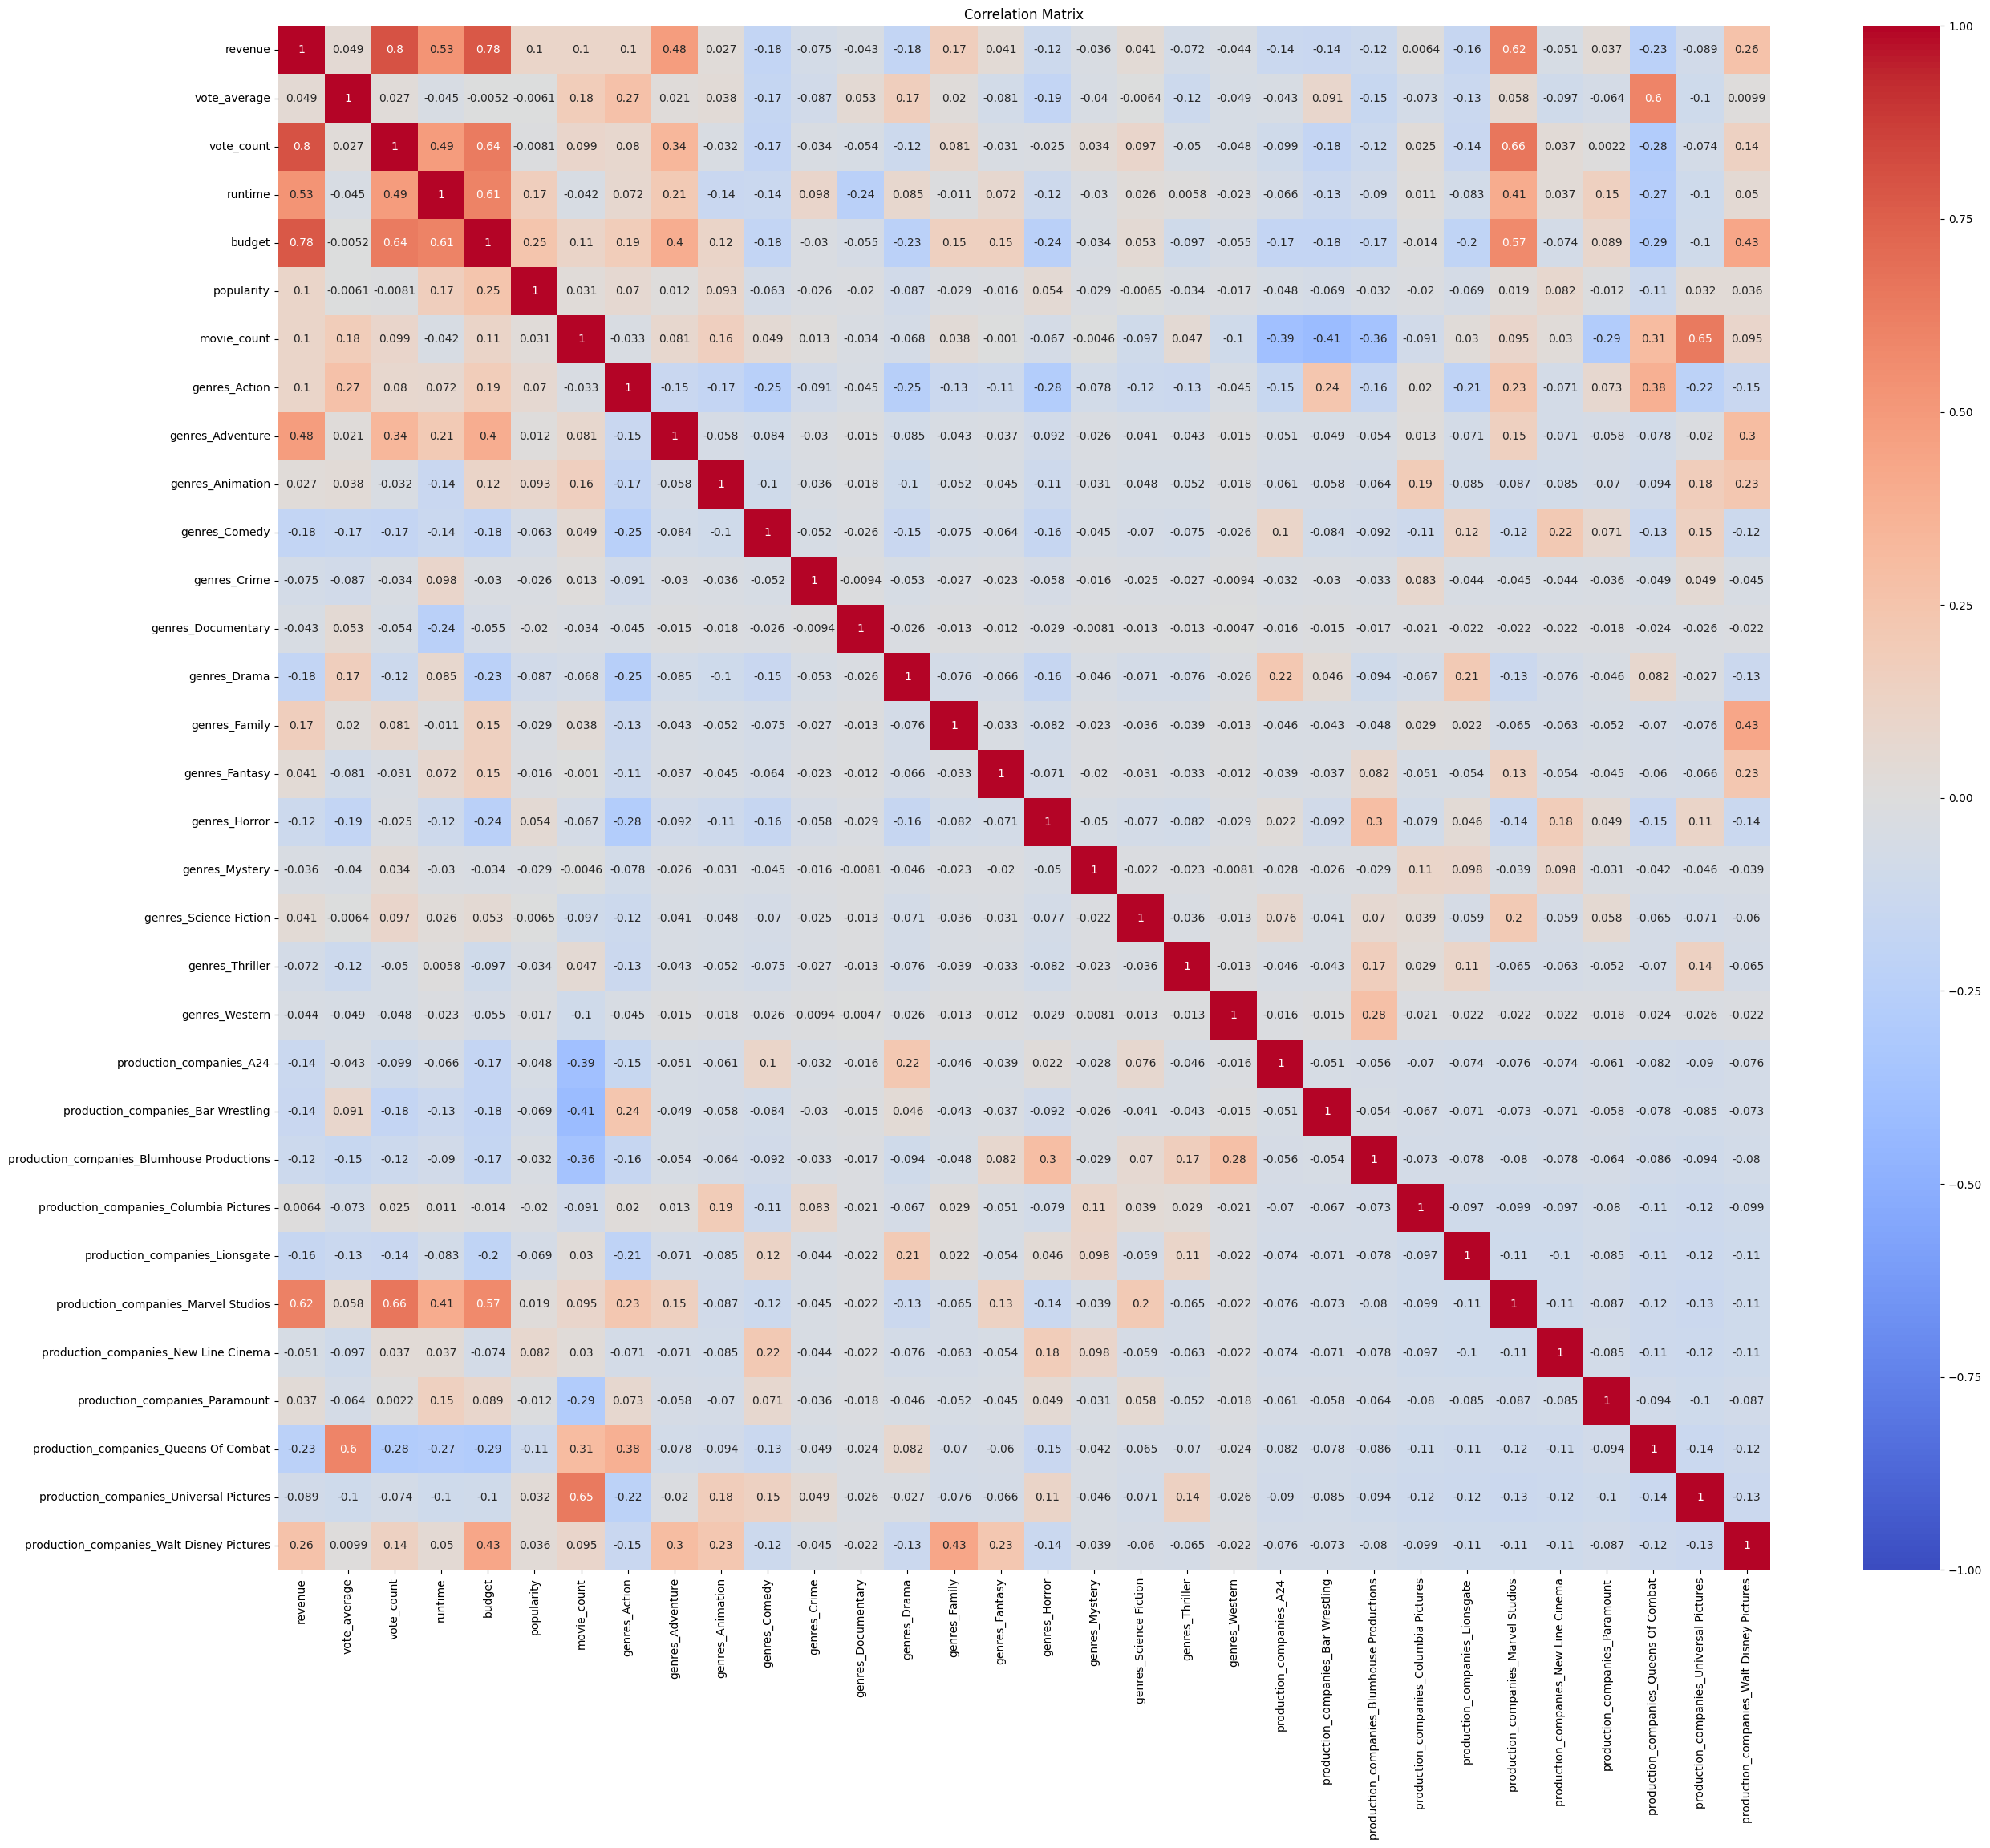

In [ ]:
plt.figure(figsize=(30, 25))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

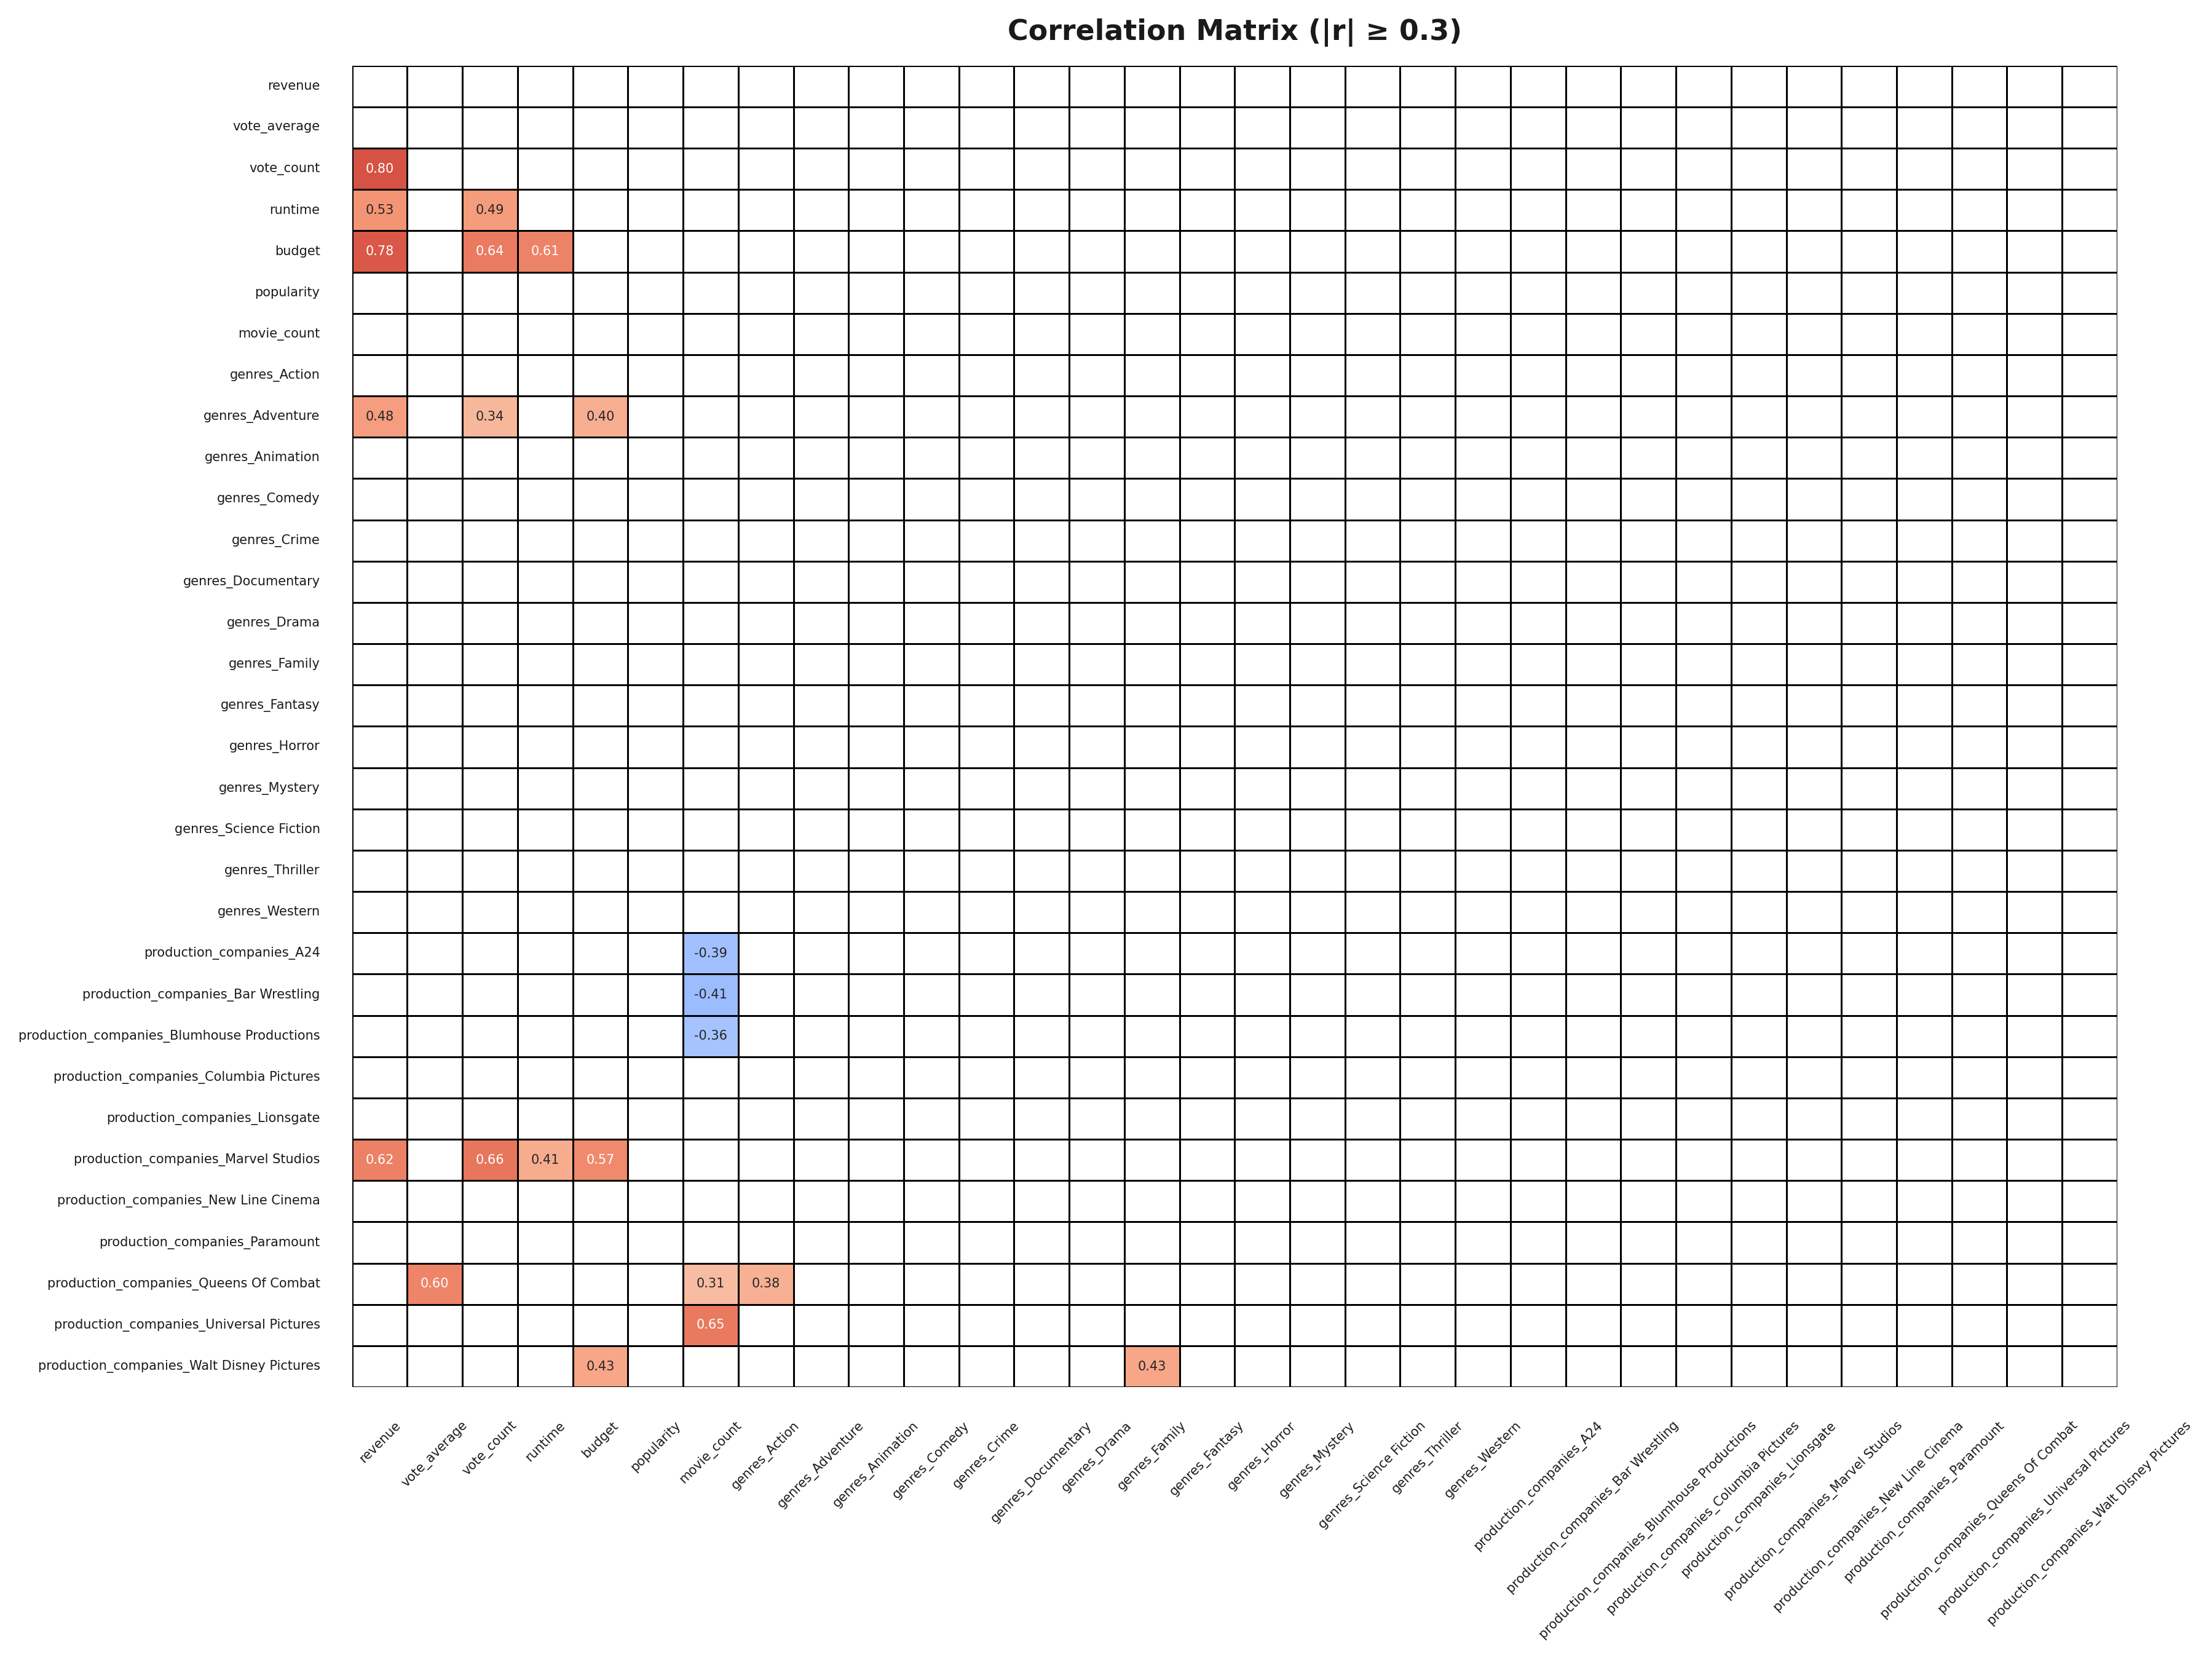

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mask upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Apply threshold to hide small correlations (abs < 0.3)
threshold = 0.3
corr_filtered = correlation_matrix.copy()
corr_filtered[np.abs(corr_filtered) < threshold] = np.nan  # hide weak correlations

# Minimalist white theme
sns.set_theme(style="white")
sns.set_context("talk", font_scale=0.8)

# Create figure
fig, ax = plt.subplots(figsize=(12, 9), dpi=300)

# Draw heatmap (no colorbar)
sns.heatmap(
    corr_filtered,
    mask=mask,
    cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f",
    annot_kws={"size":5},
    linewidths=0.3, linecolor='black',
    cbar=False
)

# Aesthetics
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

ax.set_title(
    "Correlation Matrix (|r| ≥ 0.3)",
    fontsize=11, pad=10, weight='bold', color="#1a1a1a"
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis='x', rotation=45, labelsize=5, colors="#1a1a1a")
ax.tick_params(axis='y', labelsize=5, colors="#1a1a1a")

# Remove borders for a sleek look
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(pad=0.5)
plt.show()


## 5.4 Run Model

In [ ]:
x = df_encoded[[
    'vote_average', 'vote_count', 'runtime', 'budget', 'popularity', 'movie_count',
    'genres_Action', 'genres_Adventure', 'genres_Animation', 'genres_Comedy',
    'genres_Crime', 'genres_Documentary', 'genres_Drama', 'genres_Family',
    'genres_Fantasy', 'genres_Horror', 'genres_Mystery',
    'genres_Science Fiction', 'genres_Thriller', 'genres_Western',
    'production_companies_A24', 'production_companies_Bar Wrestling',
    'production_companies_Blumhouse Productions', 'production_companies_Columbia Pictures',
    'production_companies_Lionsgate', 'production_companies_Marvel Studios',
    'production_companies_New Line Cinema', 'production_companies_Paramount',
    'production_companies_Queens Of Combat', 'production_companies_Universal Pictures',
    'production_companies_Walt Disney Pictures'
]]

y = df_encoded['revenue']

x= sm.add_constant(x)

model = sm.OLS(y,x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     25.69
Date:                Fri, 31 Oct 2025   Prob (F-statistic):           9.09e-51
Time:                        17:56:17   Log-Likelihood:                -4396.3
No. Observations:                 215   AIC:                             8855.
Df Residuals:                     184   BIC:                             8959.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Adjust

In [ ]:
x = df_encoded[[
    'vote_count','budget',
    'genres_Adventure',
    'genres_Family',
    'production_companies_Walt Disney Pictures'
]]

y = df_encoded['revenue']

x= sm.add_constant(x)

model = sm.OLS(y,x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     160.8
Date:                Thu, 30 Oct 2025   Prob (F-statistic):           1.33e-69
Time:                        21:31:23   Log-Likelihood:                -4403.6
No. Observations:                 215   AIC:                             8819.
Df Residuals:                     209   BIC:                             8839.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

# **6. Export Dataset Part 2**

In [ ]:
df_encoded.to_csv('df_encoded.csv', index=False)

# **7. Run Model Part 2**

In [ ]:
df_encoded_adjusted = pd.read_csv('df_encoded_adjusted.csv')

In [ ]:
df_encoded_adjusted.drop('release_date', axis = 1, inplace = True)

In [ ]:
df_encoded_adjusted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 36 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   revenue                                     213 non-null    int64  
 1   vote_average                                213 non-null    float64
 2   vote_count                                  213 non-null    int64  
 3   runtime                                     213 non-null    int64  
 4   budget                                      213 non-null    int64  
 5   popularity                                  213 non-null    float64
 6   profit                                      213 non-null    int64  
 7   ROI                                         213 non-null    float64
 8   movie_count                                 213 non-null    int64  
 9   genres_Action                               213 non-null    int64  
 10  genres_Adventu

In [ ]:
#Assign 'genres_Action' and 'production_companies_Universal Pictures' as baseline

x = df_encoded_adjusted[[
    'vote_average', 'vote_count', 'runtime', 'budget', 'popularity',
    'genres_Adventure', 'genres_Animation', 'genres_Comedy',
    'genres_Crime', 'genres_Documentary', 'genres_Drama', 'genres_Family',
    'genres_Fantasy', 'genres_Horror', 'genres_Mystery', 'genres_Western',
    'genres_Science Fiction', 'genres_Thriller',
    'production_companies_A24', 'production_companies_Bar Wrestling',
    'production_companies_Blumhouse Productions', 'production_companies_Columbia Pictures',
    'production_companies_Lionsgate', 'production_companies_Marvel Studios',
    'production_companies_New Line Cinema', 'production_companies_Paramount',
    'production_companies_Queens Of Combat',
    'production_companies_Walt Disney Pictures'
]]

y = df_encoded_adjusted['revenue']

x= sm.add_constant(x)

model = sm.OLS(y,x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     28.68
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           2.82e-52
Time:                        02:38:24   Log-Likelihood:                -4356.0
No. Observations:                 213   AIC:                             8768.
Df Residuals:                     185   BIC:                             8862.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

Adjust

In [ ]:
#Assign 'genres_Action' and 'production_companies_Universal Pictures' as baseline

x = df_encoded_adjusted[[
    'vote_count', 'budget',
    'genres_Adventure', 'genres_Family'
]]

y = df_encoded_adjusted['revenue']

x= sm.add_constant(x)

model = sm.OLS(y,x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     192.3
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           1.07e-68
Time:                        02:40:47   Log-Likelihood:                -4366.5
No. Observations:                 213   AIC:                             8743.
Df Residuals:                     208   BIC:                             8760.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -5.171e+07   1.82e+07  